##MACHINE LEARNING PROJECT - BASIC CUSTOMER CHURN

##Problem Statement
Customer retention is a critical challenge in the telecommunications industry, where acquiring new 
customers is significantly more expensive than retaining existing ones. High customer churn directly 
impacts revenue, profitability, and long-term business sustainability.

##Objective
The objective of this project is to analyze customer behavior and build a machine learning model that 
predicts customer churn using historical telecom customer data. By identifying customers who are likely
to discontinue their services, the organization can implement targeted retention strategies, such as 
personalized offers, improved service plans, or proactive customer support.

This project involves:
*Understanding customer demographic, service usage, contract, and billing information
*Performing data cleaning, exploratory data analysis (EDA), and feature engineering
*Building and evaluating predictive models to classify customers as churned or retained
*Interpreting model results to identify key factors influencing customer churn

In [1]:
#Importing necessary libraries
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("tele_comm.csv")
pd.set_option('display.max_columns', None)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [3]:
df.shape

(7043, 21)

There are 7043 Rows and 21 Columns

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

"""Dataset Column Descriptions
*customerID
Unique identifier assigned to each customer; used only for identification and not for modeling.
*gender
Indicates the customer’s gender (Male or Female).
*SeniorCitizen
Binary indicator showing whether the customer is a senior citizen (1 = Yes, 0 = No).
*Partner
Specifies whether the customer has a spouse or domestic partner.
*Dependents
Indicates whether the customer has dependent family members relying on them financially.
*tenure
Number of months the customer has been with the company.
*PhoneService
Indicates whether the customer has a phone service subscription.
*MultipleLines
Specifies whether the customer has multiple phone lines.
*InternetService
Type of internet service used by the customer (DSL, Fiber optic, or No internet service).
*OnlineSecurity
Indicates whether the customer subscribes to online security services.
*OnlineBackup
Specifies whether the customer has an online backup service.
*DeviceProtection
Indicates whether the customer has device protection coverage.
*TechSupport
Specifies whether the customer receives technical support services.
*StreamingTV
Indicates whether the customer uses streaming TV services.
*StreamingMovies
Indicates whether the customer uses streaming movie services.
*Contract
Type of contract the customer has (Month-to-month, One year, or Two year).
*PaperlessBilling
Indicates whether the customer uses paperless billing.
*PaymentMethod
Describes the method used by the customer to pay bills.
*MonthlyCharges
Amount charged to the customer on a monthly basis.
*TotalCharges
Total amount charged to the customer over the entire tenure.
*Churn
Target variable indicating whether the customer has discontinued the service."""

In [ ]:
df.head()

In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
#Checking the data types of columns
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
#Converting the datatype of 'TotalCharges' to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [8]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [9]:
df.sample(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1450,1735-XMJVH,Male,0,Yes,Yes,8,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.35,152.60,No
4301,7729-XBTWX,Male,0,Yes,Yes,66,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,19.75,1344.50,No
2390,1226-JZNKR,Female,0,Yes,Yes,8,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Electronic check,19.80,160.05,No
5066,7191-ADRGF,Male,0,Yes,No,44,No,No phone service,DSL,No,Yes,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),54.30,2390.45,No
4630,1852-XEMDW,Male,0,No,No,22,Yes,Yes,DSL,Yes,Yes,Yes,No,No,No,Month-to-month,No,Mailed check,65.05,1427.55,No
6936,7693-LCKZL,Male,0,Yes,Yes,5,Yes,Yes,Fiber optic,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,80.15,385.00,Yes
3703,9483-GCPWE,Male,0,No,Yes,9,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.10,190.25,No
2510,3707-GNWHM,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.25,74.25,Yes
938,2692-AQCPF,Female,0,Yes,No,65,Yes,Yes,Fiber optic,No,Yes,Yes,Yes,Yes,Yes,One year,Yes,Credit card (automatic),108.05,7118.90,No
6461,0419-YAAPX,Male,0,Yes,No,49,Yes,No,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),85.30,4297.95,No


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


There are only 11 Null Values in Total Charges

In [11]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


##Observation - 
The dataset shows significant variability in customer tenure and billing amounts, indicating diverse 
customer behavior patterns. Tenure and TotalCharges exhibit wide ranges and high dispersion, making
themstrong indicators of customer loyalty and lifetime value. MonthlyCharges show moderate variability, 
suggesting potential pricing sensitivity among customers. A small portion of missing TotalCharges 
valuesis observed, likely corresponding to newly onboarded customers.

In [12]:
df.select_dtypes(include='object').nunique().sort_values(ascending=False)

customerID          7043
PaymentMethod          4
DeviceProtection       3
Contract               3
StreamingMovies        3
StreamingTV            3
TechSupport            3
OnlineBackup           3
OnlineSecurity         3
InternetService        3
MultipleLines          3
gender                 2
PhoneService           2
Dependents             2
PaperlessBilling       2
Partner                2
Churn                  2
dtype: int64

In [13]:
df['Contract'].value_counts()

Month-to-month    3875
Two year          1695
One year          1473
Name: Contract, dtype: int64

In [14]:
df['PaymentMethod'].value_counts()

Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: PaymentMethod, dtype: int64

##DATA CLEANING

In [15]:
#Checking for Null values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [16]:
df1 = df[df['TotalCharges'].isnull()]
df1

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [17]:
#Replacing null values in 'TotalCharges' with 0 for tenure == 0
df.loc[df['tenure'] == 0, 'TotalCharges'] = 0

In [18]:
df['TotalCharges'].isnull().sum()

0

##Obsveration
Missing values in TotalCharges correspond exclusively to customers with zero tenure. Since these customers have not yet been billed, TotalCharges was logically imputed as zero to preserve business consistency.

| Option                | Correct? | Reason                        |
| --------------------- | -------- | ----------------------------- |
| Drop rows             | ❌        | Removes important churn cases |
| Median impute         | ❌        | Breaks tenure–billing logic   |
| Set to 0 for tenure=0 | ✅        | Matches real-world meaning    |

In [19]:
#Checking for duplicate values
df.duplicated().sum()

0

There are No duplicates in Dataset

In [20]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [22]:
#Outliers detection

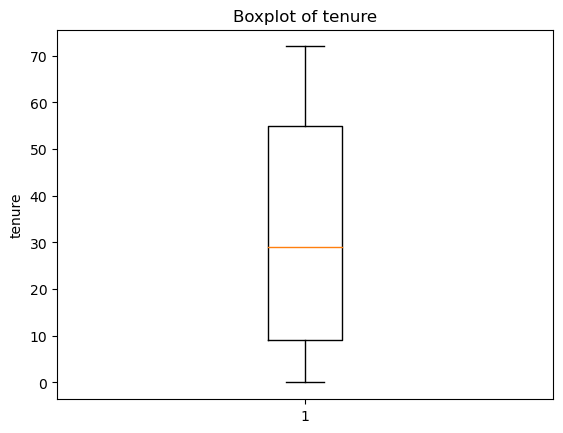

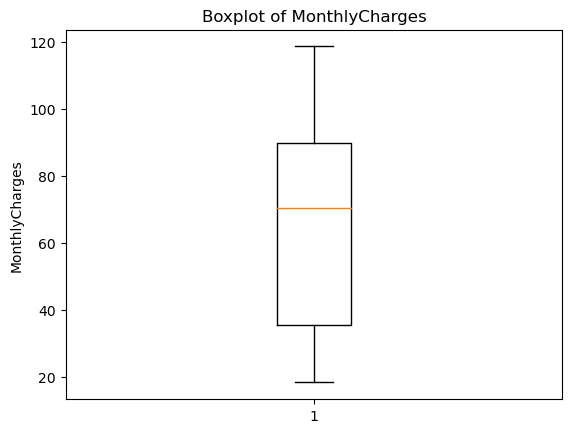

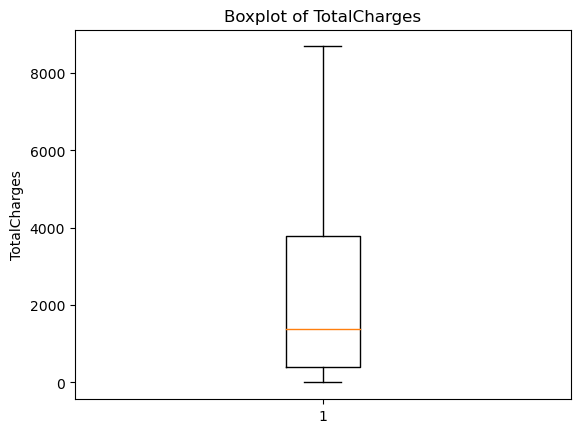

In [21]:
#Outliers detection using Box pLot
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()


In [23]:
#Outliers detection using IQR
def iqr_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound


In [24]:
for col in num_cols:
    outliers, lb, ub = iqr_outliers(df, col)
    print(f"{col}")
    print(f"Lower Bound: {lb}, Upper Bound: {ub}")
    print(f"Number of Outliers: {outliers.shape[0]}")
    print("-" * 40)


tenure
Lower Bound: -60.0, Upper Bound: 124.0
Number of Outliers: 0
----------------------------------------
MonthlyCharges
Lower Bound: -46.02499999999999, Upper Bound: 171.375
Number of Outliers: 0
----------------------------------------
TotalCharges
Lower Bound: -4683.525, Upper Bound: 8868.675
Number of Outliers: 0
----------------------------------------


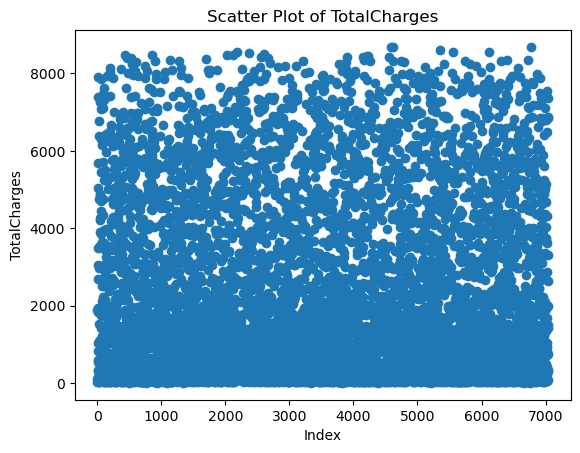

In [25]:
#Outliers detection using Scatter plot
plt.figure()
plt.scatter(df.index, df['TotalCharges'])
plt.title('Scatter Plot of TotalCharges')
plt.xlabel('Index')
plt.ylabel('TotalCharges')
plt.show()


#Observations
Outlier analysis using boxplots, scatter plots, and IQR-based thresholds did not reveal any anomalous 
values in the numerical features. Observed extreme values were consistent with valid customer behavior
and business constraints; therefore, no outlier treatment was applied.

##EXPLORATORY DATA ANALYSIS

In [26]:
target_col = df['Churn']
target_col.value_counts()

No     5174
Yes    1869
Name: Churn, dtype: int64

In [27]:
target_col.value_counts(normalize=True)*100

No     73.463013
Yes    26.536987
Name: Churn, dtype: float64

The dataset shows a significant class imbalance, with a substantially higher proportion of customers who have not churned compared to those who have.

In [28]:
#Numerical Columns in dataset
num_cols = df.select_dtypes(include=['int', 'float']).columns.tolist()
num_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [30]:
#Removing customer ID column
df.drop(columns=['customerID'], inplace=True)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
#Category columns in a dataset
category_cols = df.select_dtypes(include=['object']).columns.tolist()
category_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [32]:
#Binary category columns
binary_categorical_cols = [
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'PhoneService',
    'PaperlessBilling',
    'Churn'
]

In [33]:
#Multi Category Columns
multi_categorical_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

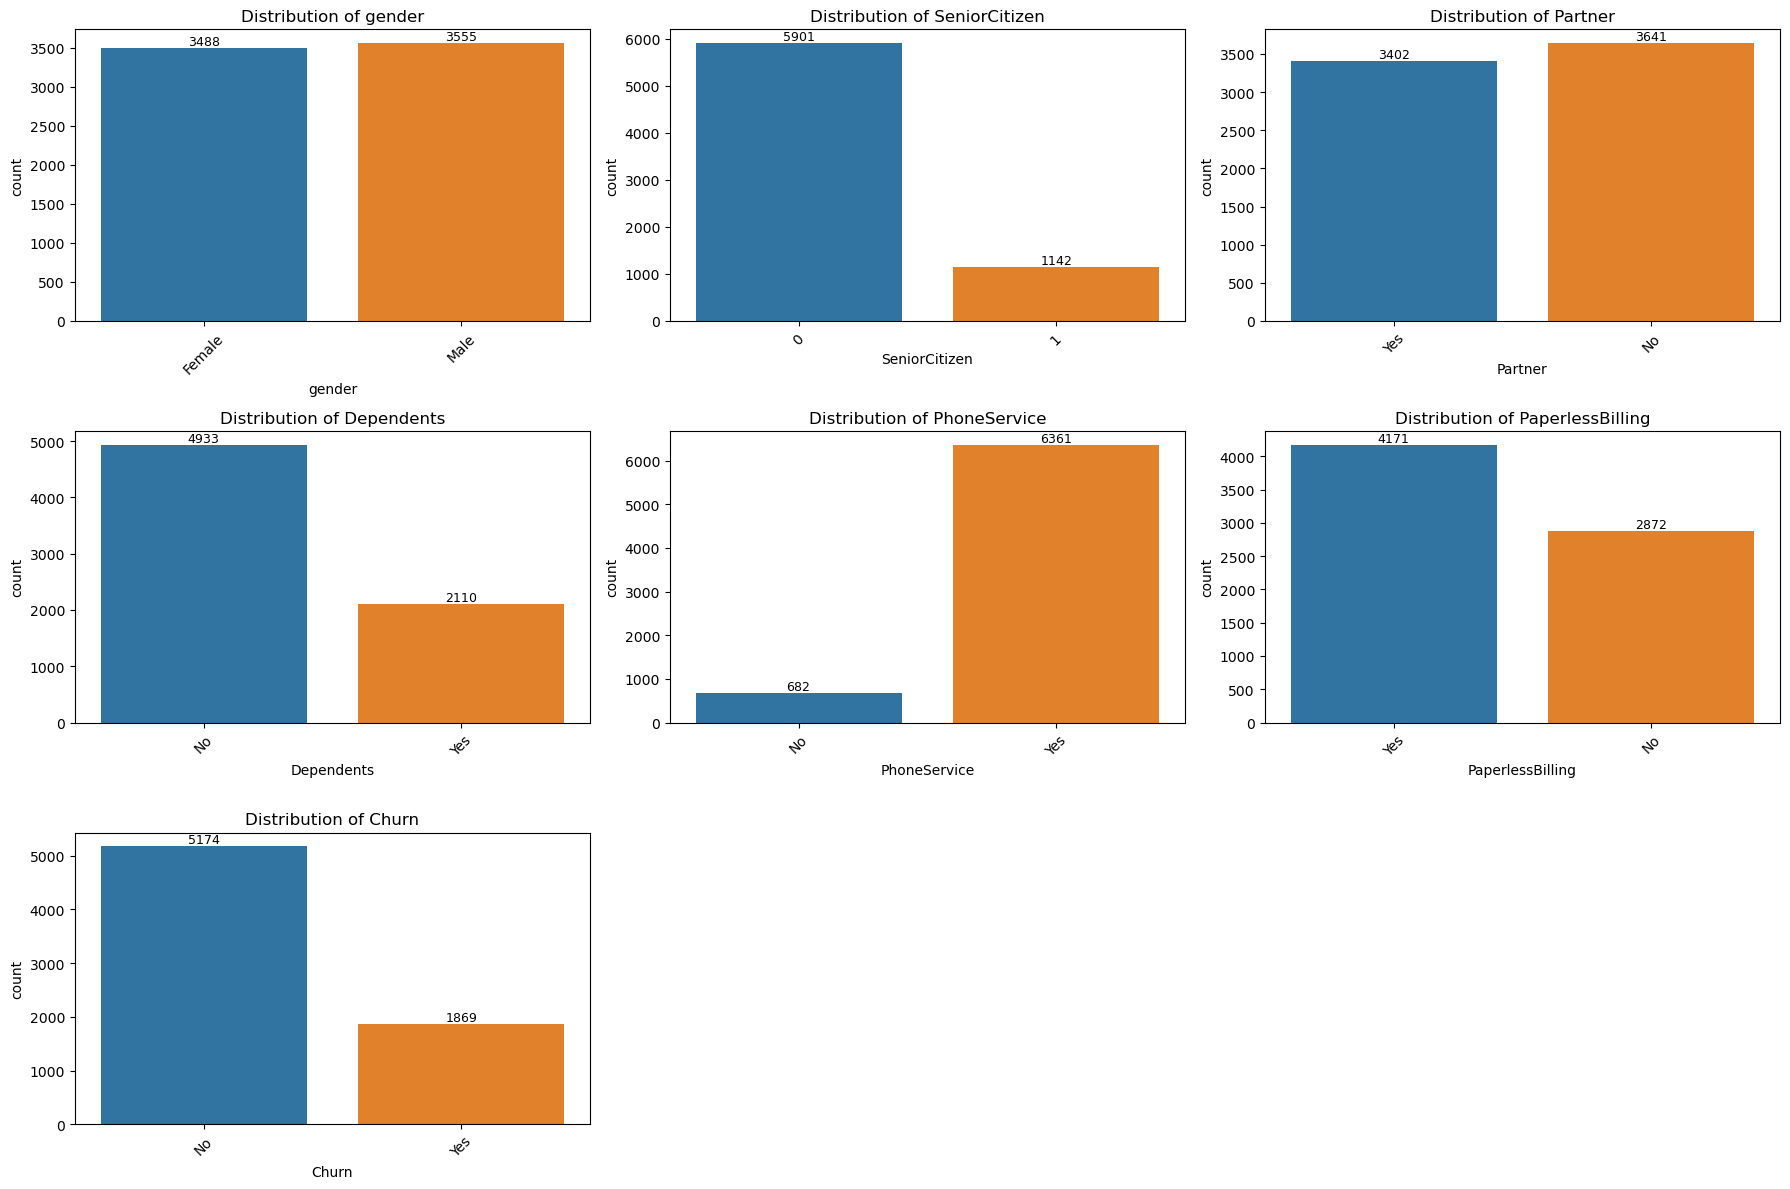

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

n_cols = 3
n_rows = math.ceil(len(binary_categorical_cols) / n_cols)

plt.figure(figsize=(n_cols*6, n_rows*4))

for i, col in enumerate(binary_categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    ax = sns.countplot(x=col, data=df)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Observations - 
* The gender distribution is nearly balanced; however, the number of male customers is slightly higher than female customers.
* A large proportion of customers are senior citizens, indicating significant representation of older users
in the dataset.
* Partner status is almost evenly distributed, though customers without partners slightly outnumber those
with partners.
* The majority of customers do not have dependents, making them the dominant group.
* Nearly all customers subscribe to phone services, showing it is a core offering.
* Paperless billing is widely adopted, with most customers opting for this billing method.

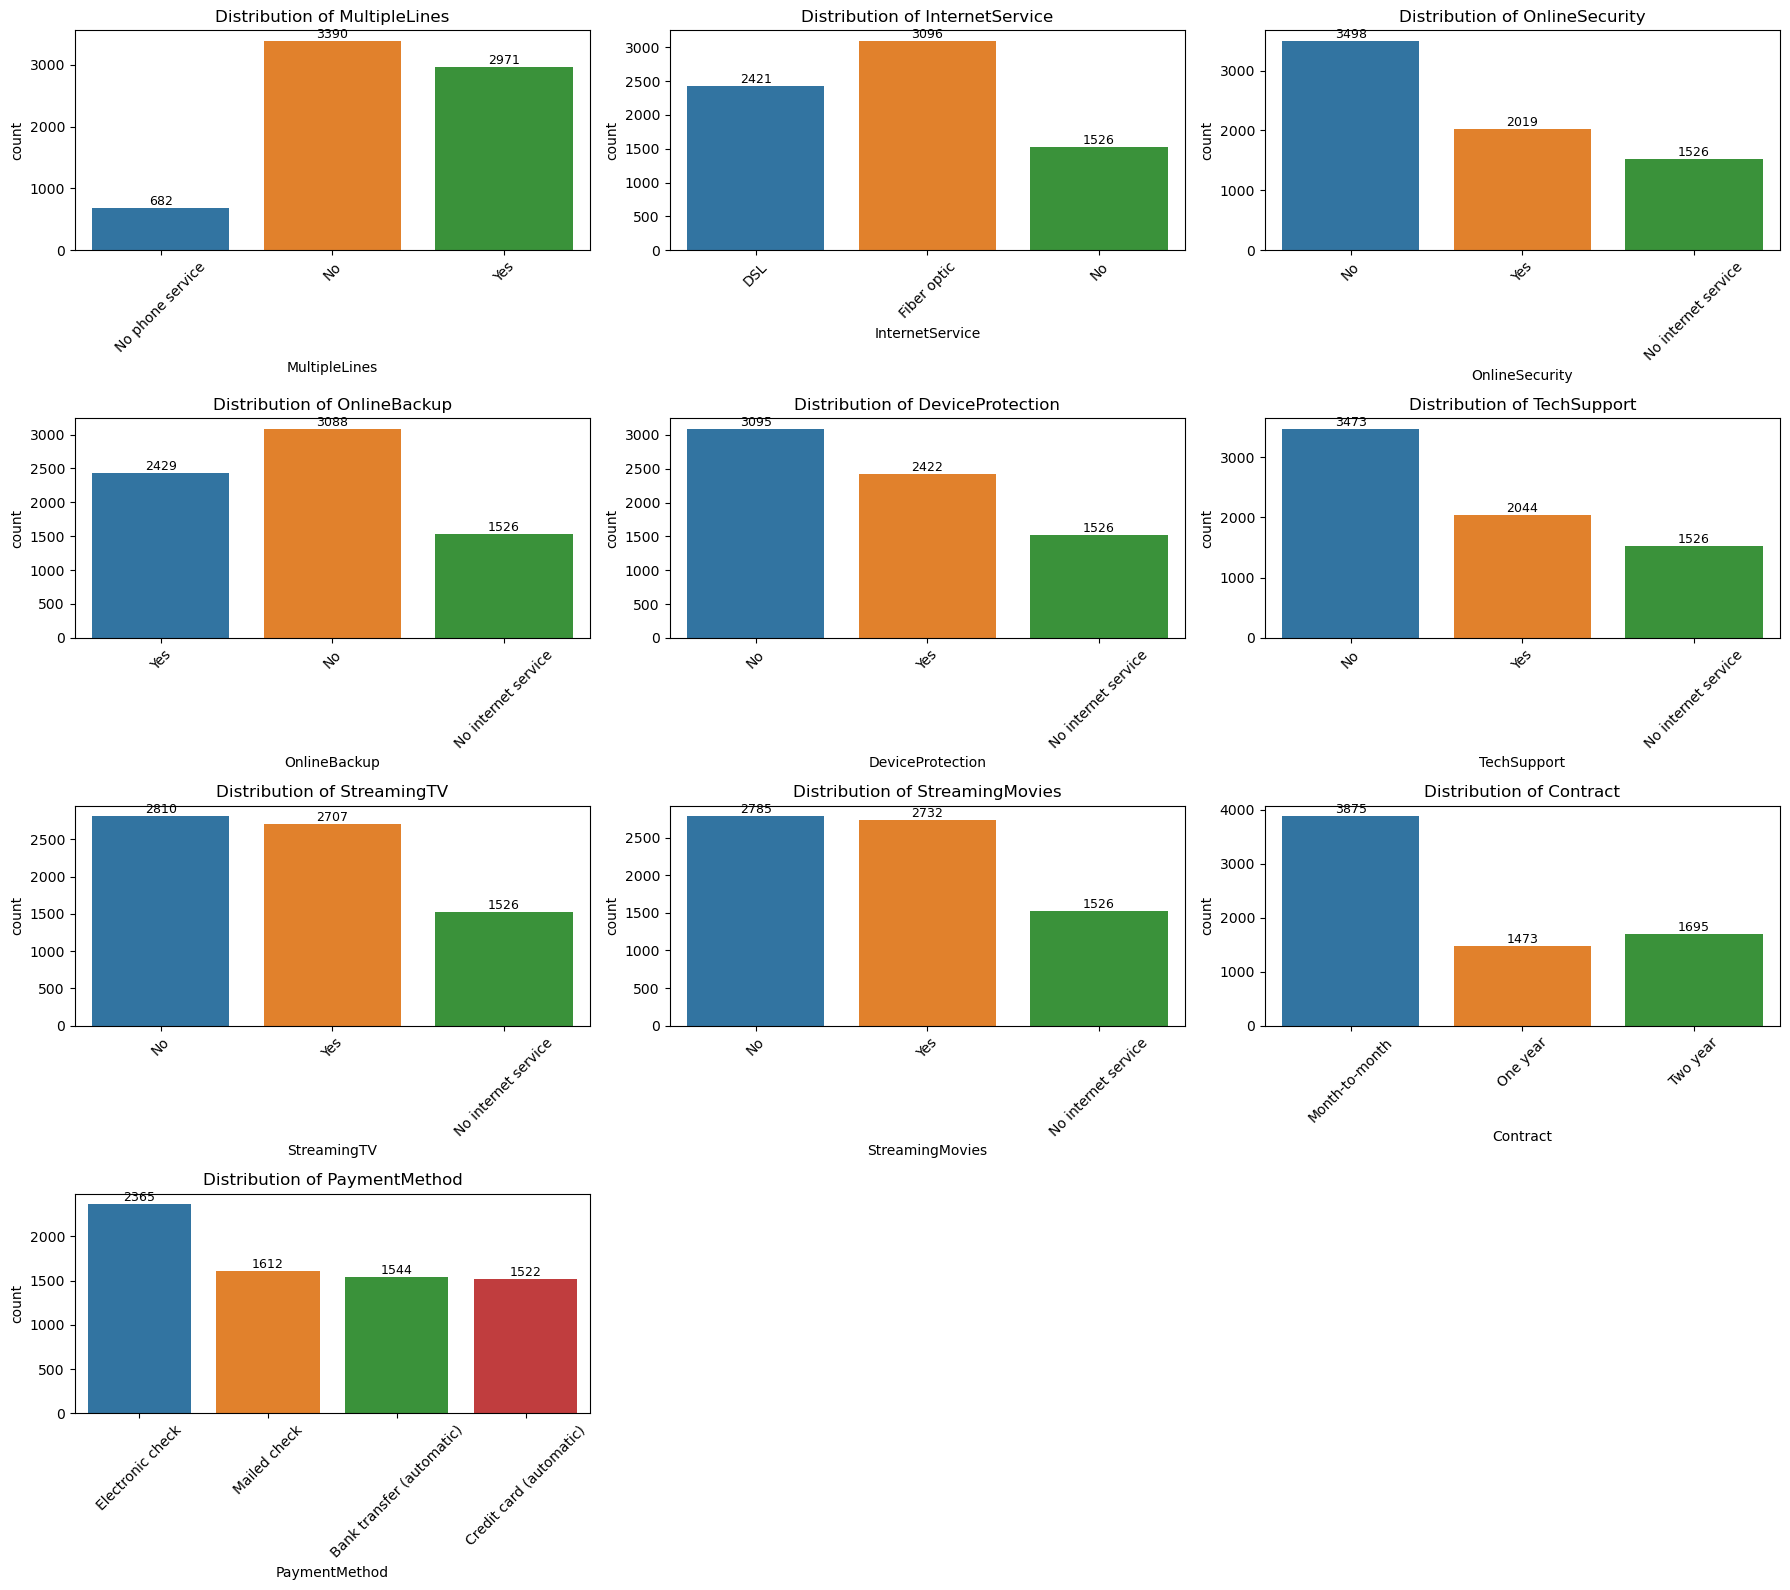

In [35]:
n_cols = 3
n_rows = math.ceil(len(multi_categorical_cols) / n_cols)

plt.figure(figsize=(n_cols*6, n_rows*4))

for i, col in enumerate(multi_categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    ax = sns.countplot(x=col, data=df)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#OBSEERVATIONS
1. Most customers have phone service; however, among them, a larger proportion use single-line connections rather than multiple lines.
2. Fiber optic is the most commonly used internet service, significantly more than DSL.
3. A majority of customers do not subscribe to online security services.
4. A relatively smaller proportion of customers use online backup and device protection services.
5. Most customers do not utilize technical support services.
6. The distribution of customers using Streaming TV and Streaming Movies services is nearly identical.
7. Month-to-month contracts are the most prevalent, followed by two-year contracts, with one-year contracts being the least common.
8. Electronic check is the most frequently used payment method, followed by mailed checks, while bank transfer and credit card payments have similar usage levels.

<Axes: xlabel='Churn', ylabel='count'>

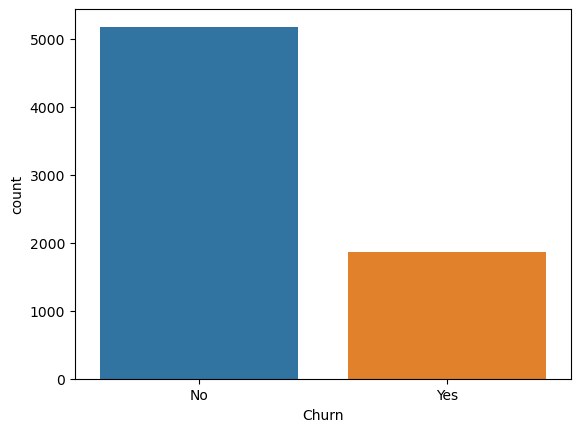

In [36]:
sns.countplot(data=df, x='Churn')

Almost 75% people are not not churned

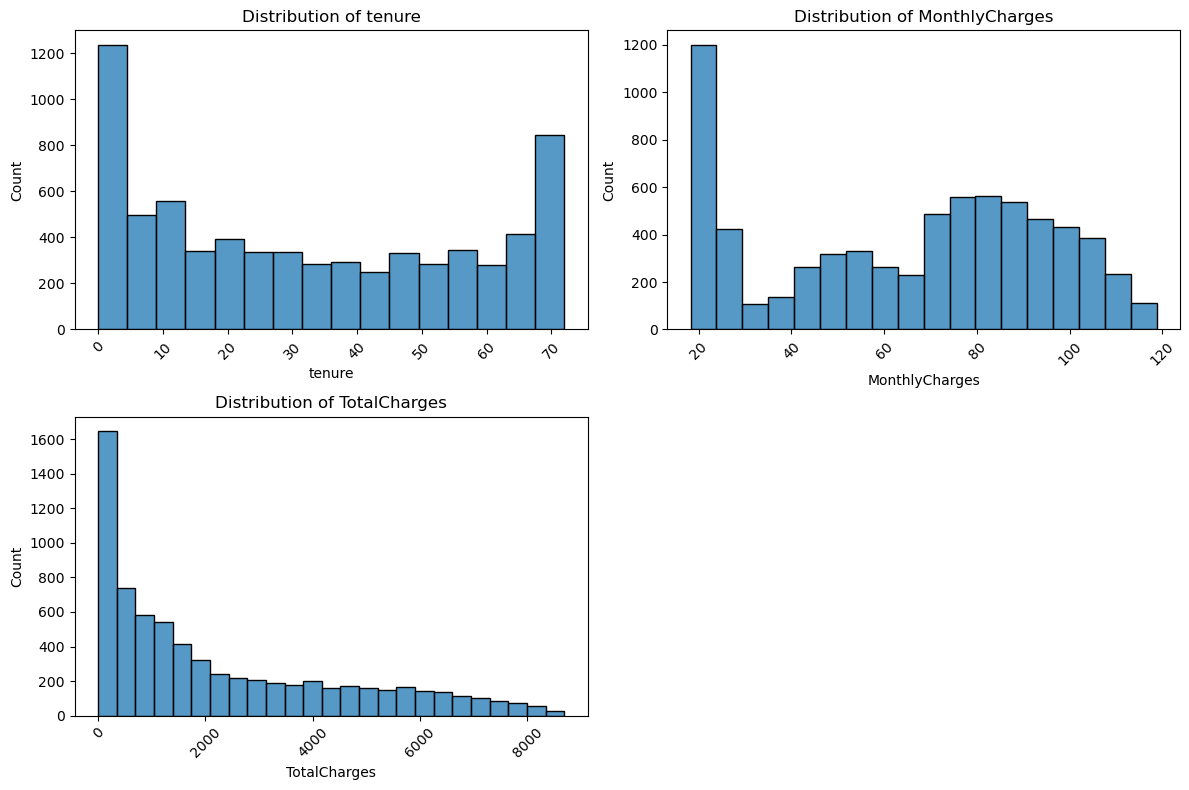

In [37]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
n_cols = 2    
n_rows = math.ceil(len(num_cols) / n_cols)
plt.figure(figsize=(n_cols*6, n_rows*4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#OBSERVATIONS
1️⃣ Tenure Distribution
Customers with very low tenure (0–10 months) and very high tenure (around 70+ months) are more frequent, while customers with mid-range tenure are relatively evenly distributed, indicating moderate variability across tenure values.
2️⃣ Monthly Charges Distribution
A large number of customers are charged the minimum monthly fee (around 20), while the majority of 
customers fall within the higher monthly charge range of approximately 70 to 110.
3️⃣ Total Charges Distribution
Higher total charges are primarily associated with long-tenure customers, while low total charges are 
dominated by recently joined customers.

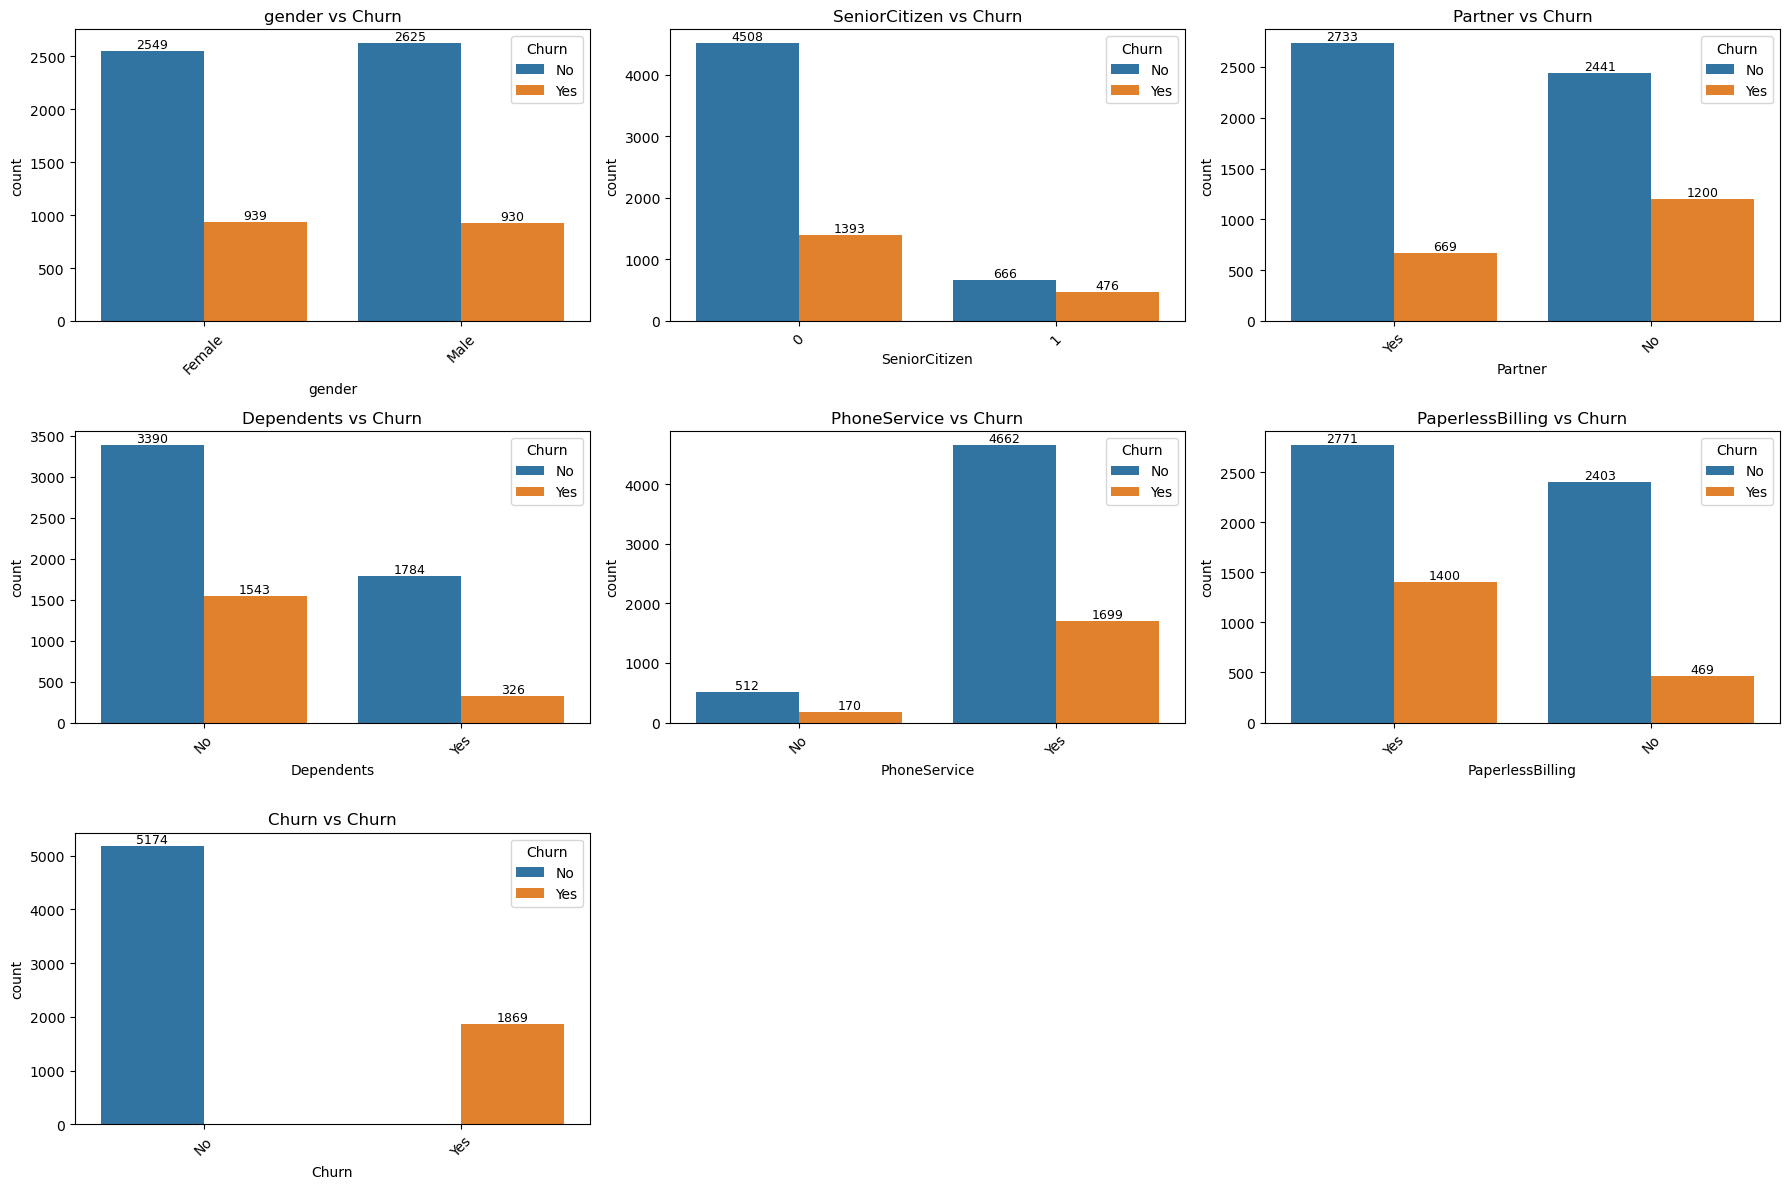

In [38]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = math.ceil(len(binary_categorical_cols) / n_cols)

plt.figure(figsize=(n_cols*6, n_rows*4))

for i, col in enumerate(binary_categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    ax = sns.countplot(x=col, hue='Churn', data=df)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##OBERVATIONS
1. The proportion of churned and non-churned customers is nearly the same across male and female customers, indicating that gender does not significantly influence churn.
2. Senior citizen customers exhibit a higher churn rate compared to non–senior citizens, suggesting age
-related differences in retention behavior.
3. Customers without partners show a comparatively higher churn rate than those with partners.
4. Customers with no dependents tend to churn more than customers who have dependents.
5. Although most customers have phone services, churn is observed more frequently among phone service 
users, primarily due to their larger representation in the dataset.
6. Customers using paperless billing show a higher churn tendency compared to those using traditional 
billing methods.

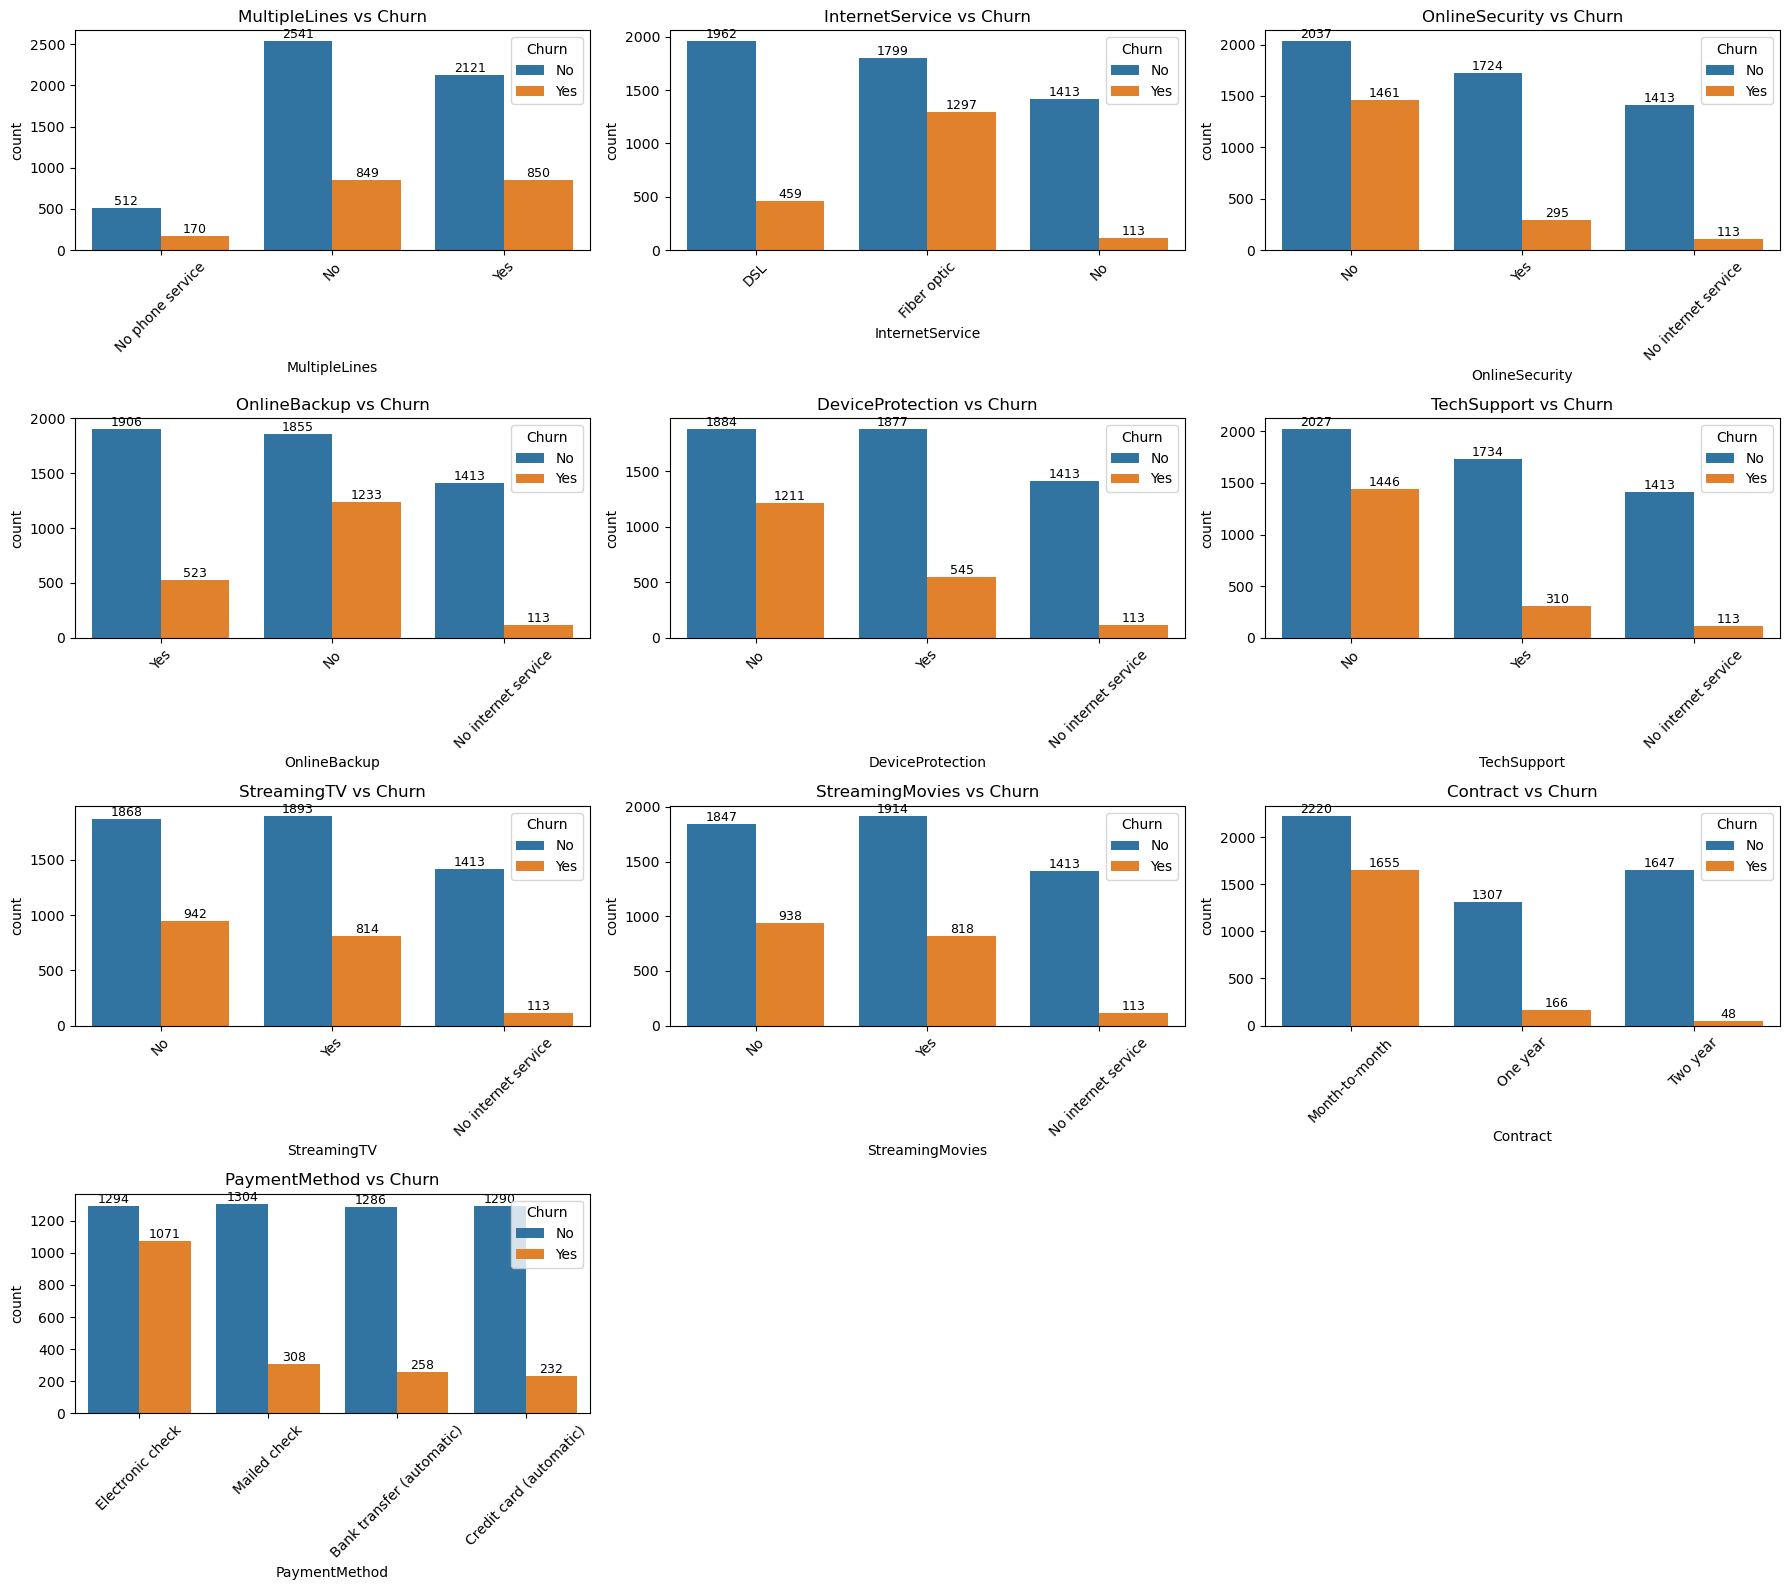

In [39]:
n_cols = 3
n_rows = math.ceil(len(multi_categorical_cols) / n_cols)

plt.figure(figsize=(n_cols*6, n_rows*4))

for i, col in enumerate(multi_categorical_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    ax = sns.countplot(x=col, hue='Churn', data=df)
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=9
            )

    plt.title(f'{col} vs Churn')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##OBSERVATIONS
1. The churn percentage is nearly the same for customers with multiple lines and those without, indicating  that multiple-line service does not significantly influence churn.
2. Customers using fiber optic internet services exhibit a higher churn rate compared to those using DSL or having no internet service. ✅ (Well-known churn driver)
3. Higher churn is observed among customers who do not subscribe to add-on services such as online 
security, online backup, device protection, and technical support.
4. The churn percentages for customers using Streaming TV and Streaming Movies services are almost 
identical, suggesting similar retention behavior across these services.
5. The highest churn rates are observed among customers on month-to-month contracts and those using 
electronic check as their payment method.

<Axes: xlabel='Churn', ylabel='tenure'>

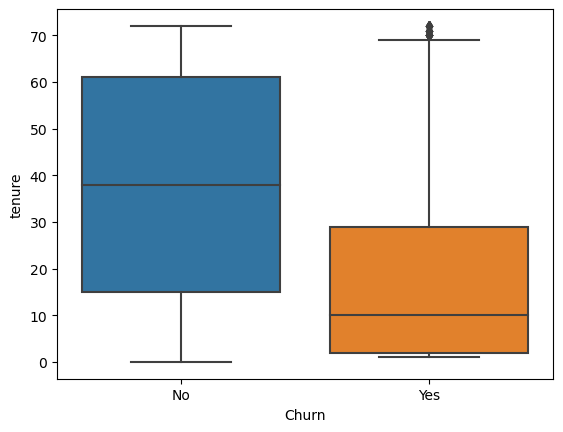

In [40]:
sns.boxplot(x='Churn', y='tenure', data=df)

##observation
The boxplot indicates that churned customers have a lower median tenure and a narrower interquartile
range, while non-churned customers show higher median tenure and a broader spread, suggesting increased
retention with longer tenure.

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

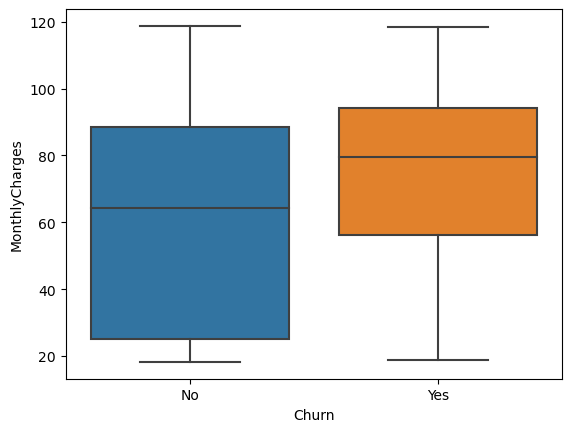

In [41]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

##Observation
Customers who churn generally have higher monthly charges, primarily ranging between 60 and 100, with a 
median around 80. In contrast, non-churned customers exhibit a broader distribution of monthly charges, 
spanning approximately from 15 to 90, indicating greater variability in pricing among retained
customers.

In [ ]:
##df['Churn'] = df['Churn'].map({1:'Yes', 0:'No'})

In [42]:
#Performing mapping for churn column for heatmap
df['Churn_num'] = df['Churn'].map({'Yes':1, 'No':0})

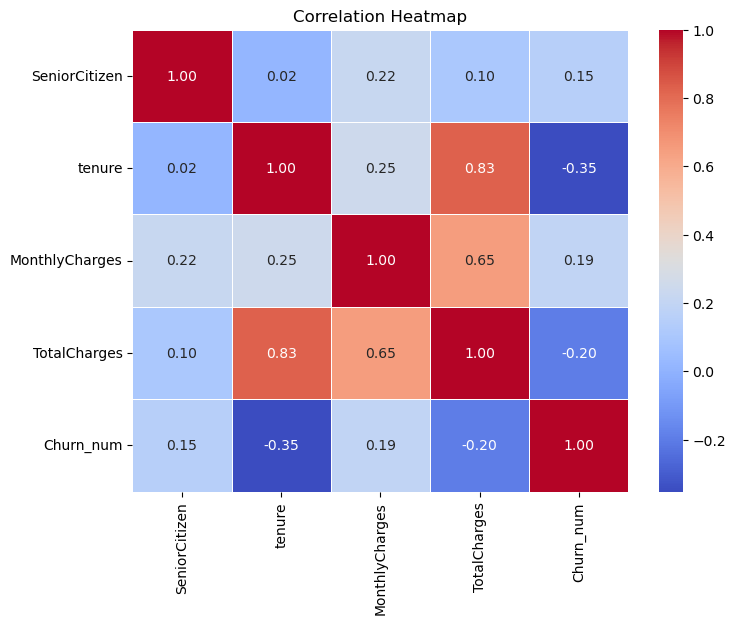

In [43]:
num_col = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(8, 6))
sns.heatmap(
    num_col.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.show()

##observations
Tenure and TotalCharges show a strong positive correlation, indicating that customers who stay longer 
naturally accumulate higher total charges. TotalCharges and MonthlyCharges are also moderately positivelycorrelated, as higher monthly bills contribute to higher cumulative charges over time.

Tenure has a moderate negative correlation with churn, suggesting that customers with shorter tenure
are more likely to churn, while long-tenure customers tend to remain with the company.

1. MonthlyCharges has a weak positive correlation with churn, indicating that customers with higher monthly charges are slightly more prone to churn.
2. TotalCharges shows a weak negative correlation with churn, which is expected since customers who churn early do not accumulate high total charges.
3. SeniorCitizen has a weak positive correlation with churn, suggesting senior citizens churn slightly 
more, but age alone is not a strong churn driver.

In [44]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [45]:
df.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: Churn, dtype: int64

In [46]:
df.groupby('Contract')['Churn_num'].mean().sort_values(ascending=False)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_num, dtype: float64

In [47]:
df.groupby('PaymentMethod')['Churn_num'].mean().sort_values(ascending=False)

PaymentMethod
Electronic check             0.452854
Mailed check                 0.191067
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Name: Churn_num, dtype: float64

In [48]:
df.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.569965,61.265124,2549.911442
Yes,17.979133,74.441332,1531.796094


<Axes: xlabel='tenure', ylabel='Density'>

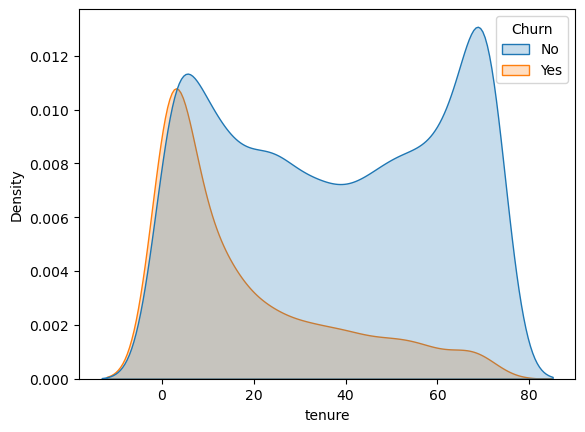

In [49]:
import seaborn as sns

sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True)


In [50]:
pd.crosstab(
    [df['Contract'], df['PaymentMethod']],
    df['Churn'],
    normalize='index'
)


Churn                                           No       Yes
Contract       PaymentMethod                                
Month-to-month Bank transfer (automatic)  0.658744  0.341256
               Credit card (automatic)    0.672192  0.327808
               Electronic check           0.462703  0.537297
               Mailed check               0.684211  0.315789
One year       Bank transfer (automatic)  0.902813  0.097187
               Credit card (automatic)    0.896985  0.103015
               Electronic check           0.815562  0.184438
               Mailed check               0.931751  0.068249
Two year       Bank transfer (automatic)  0.966312  0.033688
               Credit card (automatic)    0.977625  0.022375
               Electronic check           0.922619  0.077381
               Mailed check               0.992147  0.007853

##observation
Regardless of contract type, customers paying via electronic check consistently show higher churn rates,  indicating that payment method is a strong indicator of churn behavior.

In [51]:
df[['tenure','MonthlyCharges','TotalCharges','Churn_num']].corr()

,tenure,MonthlyCharges,TotalCharges,Churn_num
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn_num,-0.352229,0.193356,-0.198324,1.000000


In [52]:
services = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]

for col in services:
    print(col)
    print(df.groupby(col)['Churn_num'].mean())
    print('-'*30)

OnlineSecurity
OnlineSecurity
No                     0.417667
No internet service    0.074050
Yes                    0.146112
Name: Churn_num, dtype: float64
------------------------------
OnlineBackup
OnlineBackup
No                     0.399288
No internet service    0.074050
Yes                    0.215315
Name: Churn_num, dtype: float64
------------------------------
DeviceProtection
DeviceProtection
No                     0.391276
No internet service    0.074050
Yes                    0.225021
Name: Churn_num, dtype: float64
------------------------------
TechSupport
TechSupport
No                     0.416355
No internet service    0.074050
Yes                    0.151663
Name: Churn_num, dtype: float64
------------------------------
StreamingTV
StreamingTV
No                     0.335231
No internet service    0.074050
Yes                    0.300702
Name: Churn_num, dtype: float64
------------------------------
StreamingMovies
StreamingMovies
No                     0.336804
No 

##observation
Customers not utilizing value-added services consistently show a greater tendency to churn than those
who subscribe to these services, indicating the role of service engagement in customer retention.

In [53]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–12 months', '13–24 months', '25–49 months', '50–72 months']
)

pd.crosstab(df['tenure_group'], df['Churn'], normalize='index')

Churn,No,Yes
tenure_group,,
0–12 months,0.523218,0.476782
13–24 months,0.712891,0.287109
25–49 months,0.796110,0.203890
50–72 months,0.904868,0.095132


##observation
Customers with tenure between 0–12 months are more likely to churn compared to customers with 13–24 months of tenure, indicating that churn decreases as customer tenure increases.

In [67]:
high_risk = df[
    (df['Contract'] == 'Month-to-month') &
    (df['tenure'] < 12) &
    (df['OnlineSecurity'] == 'No') &
    (df['TechSupport'] == 'No') &
    (df['PhoneService'] == 'Yes') &
    (df['InternetService'] == 'Fiber optic')
]

In [68]:
churn_percentages = (
    high_risk['Churn']
    .value_counts(normalize=True) * 100
)

print(churn_percentages)

Yes    73.541384
No     26.458616
Name: Churn, dtype: float64


The cutomers who foloows this paytterns or satisy this conditons are 73.54% likely to chrun